# Risk-Return by year for a few stocks


In [1]:
# Code to download stock data

import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from datetime import date
from ipywidgets import interact, DatePicker, Output, RadioButtons 

# =============================================================================
# 1. SETUP AND DATA DOWNLOAD
# =============================================================================
tickers = ['SPY', 'NVDA', 'AIR.PA', 'MSFT', 'BA', 'JPM', 'XOM','AAPL','ANF','DPZ', 'SAP.DE', 'INTL', 'RHM.DE', 'GOOG']

# Dynamically set the date range for the last 5 full years
end_date = date.today()
start_date = date(end_date.year - 5, 1, 1) # start on Jan 1 of 5 years ago
sns.set_style("ticks")

print(f"Downloading historical stock data from {start_date} to {end_date}...")
adj_close_df = yf.download(tickers,
                           start=start_date,
                           end=end_date,
                           auto_adjust=False)['Adj Close']                        

print("\n--- Downloaded Data (First 10 Rows) ---")
print(adj_close_df.head(10))


[*********************100%***********************]  14 of 14 completed


--- Downloaded Data (First 10 Rows) ---
Ticker            AAPL     AIR.PA        ANF          BA         DPZ  \
Date                                                                   
2021-01-04  125.856682  83.992081  20.490000  202.720001  356.211914   
2021-01-05  127.412773  83.936020  21.370001  211.630005  357.938843   
2021-01-06  123.123840  84.253716  22.240000  211.029999  361.252258   
2021-01-07  127.325211  83.739792  21.209999  212.710007  359.675354   
2021-01-08  128.424225  84.188293  21.530001  209.899994  364.969299   
2021-01-11  125.438499  83.889297  23.040001  206.789993  366.574341   
2021-01-12  125.263451  84.057487  23.260000  208.410004  361.843658   
2021-01-13  127.296082  83.263260  23.700001  207.210007  358.427002   
2021-01-14  125.370422  87.131615  23.700001  209.910004  350.861603   
2021-01-15  123.649033  86.477554  24.260000  204.320007  352.203827   

Ticker           GOOG  INTL         JPM        MSFT       NVDA     RHM.DE  \
Date             


--- Annual Risk-Return Metrics (Tidy Format) ---
   Year  Ticker  Mean_Return  Std_Return  Count  Annual_Return  Annual_Risk
0  2021    AAPL     0.001409    0.015758    251       0.380610     0.250155
1  2021  AIR.PA     0.001082    0.020675    257       0.249972     0.328200
2  2021     ANF     0.002659    0.032922    251       0.699854     0.522621
3  2021      BA     0.000221    0.022426    251      -0.006906     0.355995
4  2021     DPZ     0.001741    0.016110    251       0.499422     0.255734
5  2021    GOOG     0.002166    0.014934    251       0.674299     0.237068
6  2021     JPM     0.001104    0.013469    251       0.289636     0.213818
7  2021    MSFT     0.001855    0.013206    251       0.557900     0.209631
8  2021    NVDA     0.003625    0.028396    251       1.244762     0.450773
9  2021  RHM.DE    -0.000034    0.013868    254      -0.032446     0.220145

Generating plot...


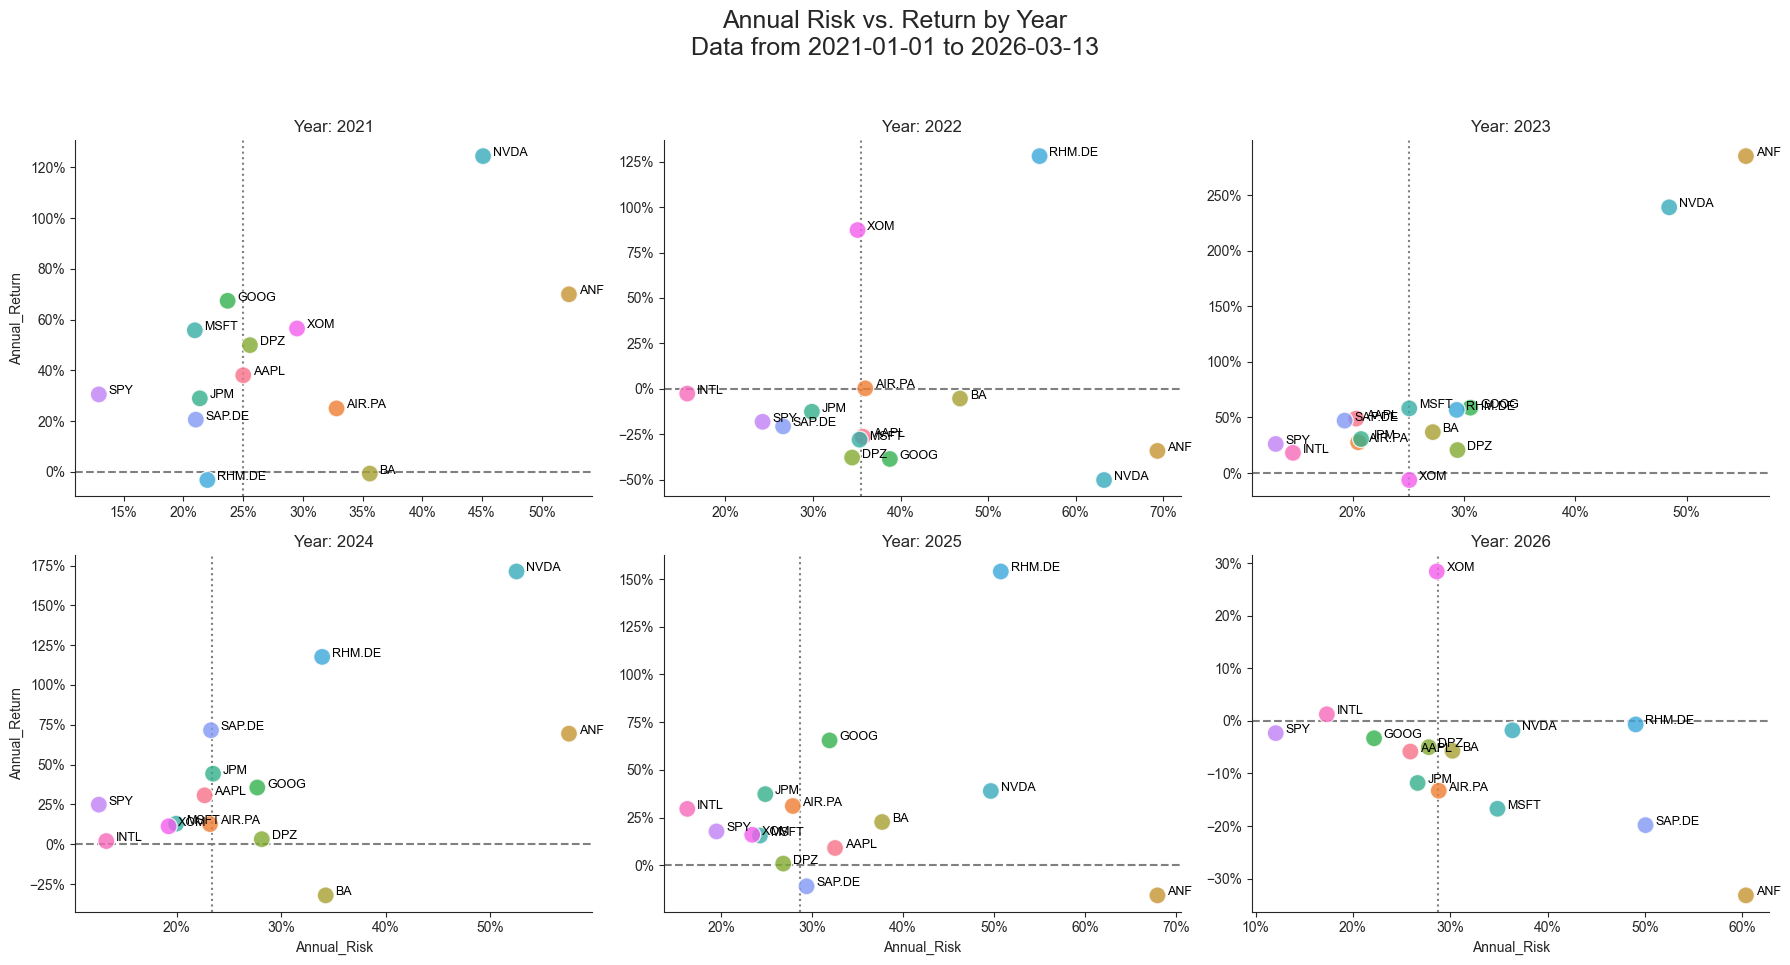

In [5]:

# =============================================================================
# 2. DATA TRANSFORMATION TO LONG FORMAT- MELT THE DOWNLOADED DATA
# =============================================================================
long_format_df = (adj_close_df.reset_index()
            .melt(id_vars='Date',
                  var_name='Ticker',
                  value_name='Adj_Close')
            .dropna()
            .sort_values(['Ticker', 'Date'])
            .reset_index(drop=True))

daily_returns_long_df = (
    long_format_df
    .sort_values(['Ticker', 'Date'])
    .assign(Daily_Return=lambda df: df.groupby('Ticker')['Adj_Close'].pct_change())
    .dropna()
    .reset_index(drop=True)
)

# =============================================================================
# 3. ANNUAL RISK-RETURN ANALYSIS IN LONG FORMAT
# =============================================================================
TRADING_DAYS = 252

annual_metrics = (daily_returns_long_df
                  .assign(Year=lambda x: x['Date'].dt.year)
                  .groupby(['Year', 'Ticker'])
                  .agg(
                      Mean_Return=('Daily_Return', 'mean'),
                      Std_Return=('Daily_Return', 'std'),
                      Count=('Daily_Return', 'count'),
                      Annual_Return=('Daily_Return', lambda x: (1 + x).prod() - 1)
                  )
                  .reset_index())

# Annualize risk only (return is already compounded above)
annual_metrics['Annual_Risk'] = annual_metrics['Std_Return'] * np.sqrt(TRADING_DAYS)


print("\n--- Annual Risk-Return Metrics (Tidy Format) ---")
print(annual_metrics.head(10).to_string())

# =============================================================================
# 4. PLOTTING WITH SEABORN AND DIRECT LABELS (MODIFIED)
# =============================================================================
print("\nGenerating plot...")
g = sns.relplot(
    data=annual_metrics,
    x='Annual_Risk',
    y='Annual_Return',
    hue='Ticker',
    # --- CHANGE 2: Removed 'style' to make all markers dots ---
    # style='Ticker', # This line was removed
    col='Year',
    col_wrap=3,
    s=150,  # Slightly smaller dots
    alpha=0.8,
    height=5,
    aspect=1.2,
    kind='scatter',
    legend=False,
    facet_kws={'sharex': False, 'sharey': False} 
)

# --- Use a single, more robust loop for all subplot customizations ---
for year, ax in g.axes_dict.items():
    ax.set_title(f"Year: {year}")
    year_data = annual_metrics[annual_metrics['Year'] == year]

    # Add direct text labels to each point
    for idx, row in year_data.iterrows():
        ax.annotate(
            text=row['Ticker'],
            xy=(row['Annual_Risk'], row['Annual_Return']),
            color='black',
            size=9,
            # --- CHANGE 1: Font weight is now 'normal' instead of 'semibold' ---
            weight='normal',
            xytext=(7, 0), # Adjusted offset for better readability with dots
            textcoords='offset points'
        )

    # Customize the axes and add reference lines
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
    ax.axhline(0, ls='--', color='gray', zorder=0)

    if not year_data.empty:
        median_risk = year_data['Annual_Risk'].median()
        ax.axvline(median_risk, ls=':', color='gray', zorder=0, label='Median Risk')

# --- Add main title with the specified date range ---
title_str = f"Annual Risk vs. Return by Year\nData from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}"
g.fig.suptitle(title_str, fontsize=18)

# Adjust subplot layout to prevent title overlap
g.fig.tight_layout(rect=[0, 0.02, 1, 0.95])

plt.show()